In [1]:
# ----------------------------------------------------------------------------
# Title: Term Project - Milestone 1
# Author: Surenther Selvaraj
# Date: 25 Mar 2026
# Modified By: Surenther Selvaraj
# ----------------------------------------------------------------------------

### Summary of Analysis
This analysis evaluates the National Database of Childcare Prices (NDCP) spanning 2008 to 2018 to assess the economic burden of childcare on American families. Utilizing a robust dataset of 34,567 observations, the study examines the relationship between Median Household Income (MHI) and the costs of infant and preschool care. The core of this analysis focuses on the "Affordability Gap"—the difference between the actual annualized cost of care and the 7% affordability benchmark set by the U.S. Department of Health and Human Services (HHS). By examining the data across a decade, the analysis identifies systemic trends in cost escalation and its potential impact on the Female Labor Force Participation Rate (FLFPR), which averaged approximately 70% across the study period.

#### Data Analysis


Average Infant Care Cost as % of Income: 16.39%
HHS Affordability Benchmark: 7.00%
Gap: 9.39% above benchmark.

Maximum Recorded Burden: 54.30% of income in Year 2018


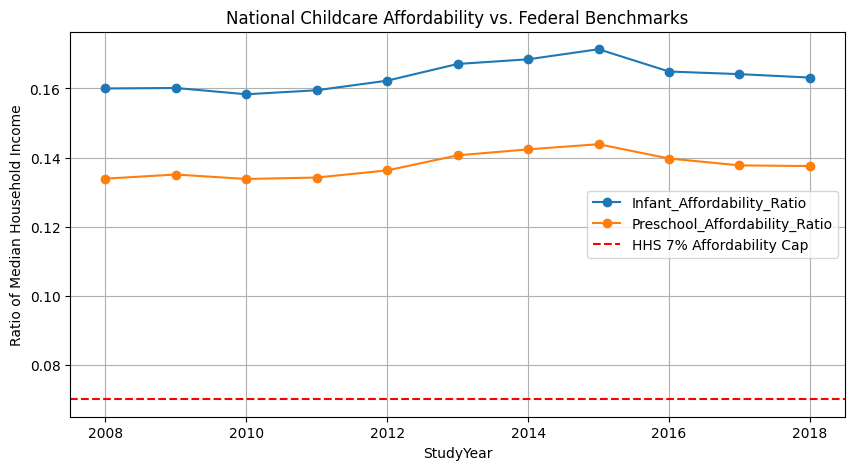

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the full dataset
df = pd.read_excel('nationaldatabaseofchildcareprices.xlsx')

# Annualizing weekly costs (Price * 52)
df['Annual_MCInfant'] = df['MCInfant'] * 52
df['Annual_MCPreschool'] = df['MCPreschool'] * 52

# Affordability Ratios (Cost / Median Household Income)
df['Infant_Affordability_Ratio'] = df['Annual_MCInfant'] / df['MHI']
df['Preschool_Affordability_Ratio'] = df['Annual_MCPreschool'] / df['MHI']

# # Comprehensive Summary Statistics
# print("--- National Childcare Economic Summary (2008-2018) ---")
# summary_stats = df[['MHI', 'MCInfant', 'MCPreschool', 'Infant_Affordability_Ratio', 'FLFPR_20to64']].describe()
# # print(summary_stats)

# National Affordability Benchmarking
avg_infant_ratio = df['Infant_Affordability_Ratio'].mean()
hhs_benchmark = 0.07
print(f"\nAverage Infant Care Cost as % of Income: {avg_infant_ratio:.2%}")
print(f"HHS Affordability Benchmark: {hhs_benchmark:.2%}")
print(f"Gap: {avg_infant_ratio - hhs_benchmark:.2%} above benchmark.")

# Identifying Extremes (The 'Childcare Deserts' or High-Burden Areas)
max_burden = df.loc[df['Infant_Affordability_Ratio'].idxmax()]
print(f"\nMaximum Recorded Burden: {max_burden['Infant_Affordability_Ratio']:.2%} of income in Year {max_burden['StudyYear']}")

# Visualizing the National Trend
yearly_avg = df.groupby('StudyYear')[['Infant_Affordability_Ratio', 'Preschool_Affordability_Ratio']].mean()
yearly_avg.plot(kind='line', marker='o', figsize=(10,5))
plt.axhline(y=0.07, color='r', linestyle='--', label='HHS 7% Affordability Cap')
plt.title('National Childcare Affordability vs. Federal Benchmarks')
plt.ylabel('Ratio of Median Household Income')
plt.legend()
plt.grid(True)

#### Findings

* <b>The Affordability Crisis:</b> The average cost for infant center-based care ($146.05/week) consumes 16.39% of the median household income. This is more than double the federal recommendation of 7%, representing a massive 9.39% "affordability gap."

* <b>Staggering Extremes:</b> The financial burden is not uniform. While the median burden is roughly 16%, some regions reached a maximum recorded burden of 54.3% in 2018, meaning childcare costs swallowed more than half of the median household’s pre-tax income.

* <b>Preschool Pressure:</b> Even as children age, relief is minimal. Preschool care remains high, averaging 13.81% of household income, nearly twice the recommended limit.

* <b> Income Stagnation vs. Price Growth: </b> With a mean MHI of $46,432 and standard deviations in prices reaching $53.69 per week, the data suggests that for many low-to-middle-income families, the cost of center-based care is functionally prohibitive, likely forcing a reliance on informal care or impacting workforce participation.

#### Assumptions

* <b>Full-Time Care:</b> Weekly prices (MCInfant, MCPreschool) are assumed to represent full-time care (approx. 40 hours per week).

* <b>Gross Income Ratios:</b> Affordability ratios are calculated using gross Median Household Income. The burden on "take-home" or net pay is likely significantly higher.

* <b> Data Integrity:</b> It is assumed that the extreme outliers (e.g., 54.3% burden) are accurate reflections of local market conditions rather than data entry errors.

#### Items for Clarification

* <b>Inflation Adjustment:</b> It is necessary to clarify if the MHI figures across the decade are inflation-adjusted to ensure that the "Affordability Ratio" accurately reflects purchasing power over time.

* <b> Cost Composition:</b> Clarification on whether these prices include additional fees (registration, supplies) or if they represent the base tuition only.

#### Direction of Story & Target Audience

* <b> The Message: </b> "The 16% Reality: Why Childcare is the New Infrastructure Crisis." The narrative will focus on how the current market price is nearly 2.5 times the federal definition of "affordable," effectively acting as a tax on working families.

* <b> Target Audience: </b> Federal and State Labor Departments. This data provides the empirical evidence needed to argue for increased subsidy ceilings and expanded tax credits.

#### Mediums

* <b> National Affordability Map: </b> A geospatial visualization highlighting counties where the "Affordability Gap" exceeds 10%.

* <b> Executive Briefing Table: </b> A summary table comparing the average cost of care versus the HHS 7% benchmark by year.

* <b> Cost-Benefit Infographic: </b> A visual representation of the "Work-to-Pay-for-Care" ratio, showing how many hours a median earner must work just to cover childcare costs.

#### References

U.S. Department of Labor. (2023). National Database of Childcare Prices (NDCP). Women's Bureau. https://www.dol.gov/agencies/wb/topics/childcare